# Hyperspectral Image Classification with CNN and Transformer

**Author:** Alessandro Carotenuto  
**Student ID:** 1847282  
**Dataset:** Pavia University  

## Project aim

The project aims to classify land-cover pixels in a hyperspectral image.
A spatial-spectral patch centered on each labeled pixel is used as input.
A CNN learns local features, while a lightweight Transformer models non-local context.

## Setup 

### Experiment Configuration

In [1]:
# Standard library imports
from pathlib import Path
import sys

# Third-party imports
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import torch
import torch.nn as nn
from scipy.io import loadmat
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
)
from torch.utils.data import DataLoader, Dataset

# Project paths and local imports
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from utils import (
    DataSplitType,
    LRSchedulingType,
    PatchSize,
    PaviaClass,
    RunMode,
    SplitName,
)

data_dir = project_root / "data" / "raw"
cube_path = data_dir / "PaviaU.mat"
ground_truth_path = data_dir / "PaviaU_gt.mat"

# Dataset and few-shot split
SPLIT_SEED = 42
DATA_SPLIT_TYPE = DataSplitType.RANDOM
TRAIN_SAMPLES_PER_CLASS = 10
VALIDATION_SAMPLES_PER_CLASS = 5
NUM_CLASSES = len(PaviaClass) - 1
LABELED_CLASS_IDS = tuple(
    int(label) for label in PaviaClass
    if label != PaviaClass.UNLABELED
)
SPLIT_NAMES = tuple(split_name.value for split_name in SplitName)
class_names = {
    int(label): label.display_name for label in PaviaClass
}

# Patch extraction and visualisation
PATCH_SIZE = PatchSize.PAPER
PATCH_RADIUS = int(PATCH_SIZE) // 2
BANDS_TO_SHOW = (10, 50, 90)

# Data loading
BATCH_SIZE = 32
NUM_WORKERS = 0
TRAINING_SEED = 100

# Model
FEATURE_CHANNELS = 128

# Training
EPOCHS = 150
SMOKE_TEST_EPOCHS = 3
RUN_FULL_TRAINING = True
LEARNING_RATE = 0.00008
LR_SCHEDULING = LRSchedulingType.FIXED

# Small-batch overfitting check
OVERFIT_LEARNING_RATE = 0.003
OVERFIT_MIN_STEPS = 50
OVERFIT_MAX_STEPS = 250
OVERFIT_TARGET_LOSS = 0.05

print("Cube:", cube_path)
print("Ground truth:", ground_truth_path)
print("Patch size:", int(PATCH_SIZE))
print("Split seed:", SPLIT_SEED)
print("Data split:", DATA_SPLIT_TYPE.value)
print("Training seed:", TRAINING_SEED)
print("Run mode:", RunMode.FULL if RUN_FULL_TRAINING else RunMode.SMOKE)

Cube: c:\Users\alex1\Documents\Cloned Repositories\Hyperspectral-Neural-Networks-Project\data\raw\PaviaU.mat
Ground truth: c:\Users\alex1\Documents\Cloned Repositories\Hyperspectral-Neural-Networks-Project\data\raw\PaviaU_gt.mat
Patch size: 15
Split seed: 42
Training seed: 100
Run mode: full


### Loading MATLAB Files

In [2]:
cube_file = loadmat(cube_path)
ground_truth_file = loadmat(ground_truth_path)

print(cube_file.keys())
print(ground_truth_file.keys())

dict_keys(['__header__', '__version__', '__globals__', 'paviaU'])
dict_keys(['__header__', '__version__', '__globals__', 'paviaU_gt'])


### Dimension Check

In [3]:
cube = cube_file["paviaU"]
ground_truth = ground_truth_file["paviaU_gt"]

print("Cube:", cube.shape, cube.dtype)
print("Ground truth:", ground_truth.shape, ground_truth.dtype)
print("Cube range:", cube.min(), cube.max())
print("Labels:", np.unique(ground_truth))

Cube: (610, 340, 103) uint16
Ground truth: (610, 340) uint8
Cube range: 0 8000
Labels: [0 1 2 3 4 5 6 7 8 9]


### Class Count

In [4]:
labels, counts = np.unique(ground_truth, return_counts=True)

for label, count in zip(labels, counts):
    print(label, class_names[label], count)

0 Unlabeled 164624
1 Asphalt 6631
2 Meadows 18649
3 Gravel 2099
4 Trees 3064
5 Painted metal sheets 1345
6 Bare Soil 5029
7 Bitumen 1330
8 Self-Blocking Bricks 3682
9 Shadows 947


### Active Patch Shape

In [5]:
print("Patch size:", int(PATCH_SIZE))
print("Patch radius:", PATCH_RADIUS)

Patch size: 15
Patch radius: 7


## Dataset Exploration and Dataloaders

### Spectral Bands and Ground Truth

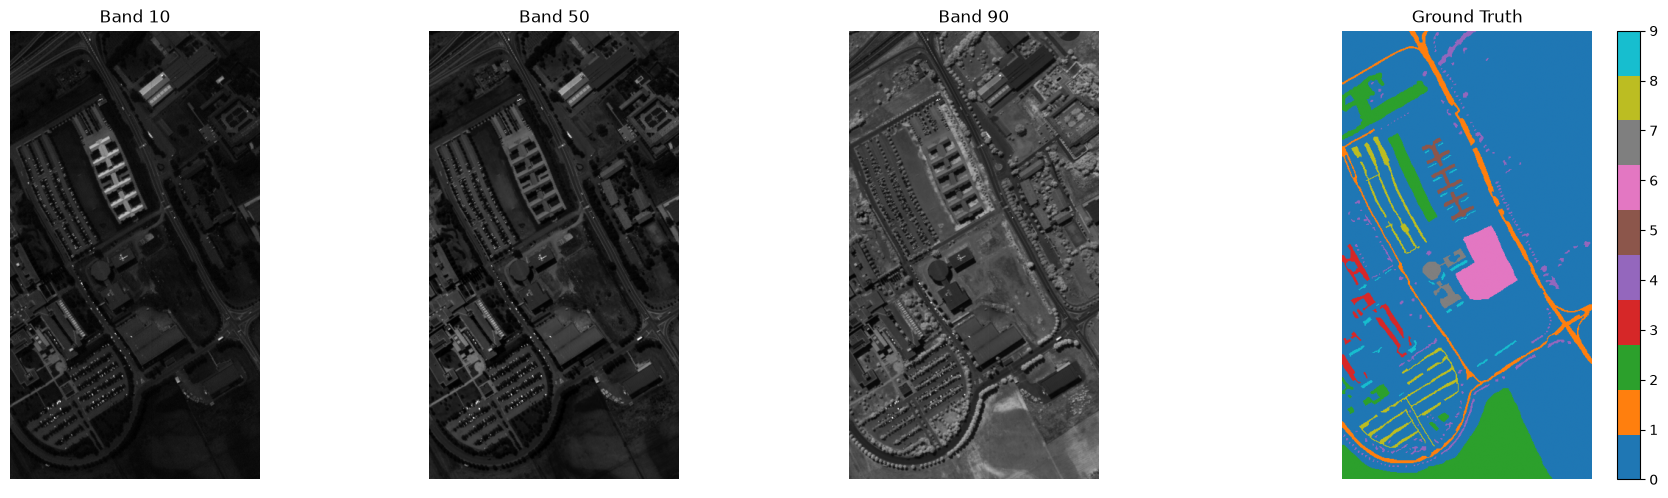

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for axis, band_index in zip(axes[:3], BANDS_TO_SHOW):
    axis.imshow(cube[:, :, band_index], cmap="gray")
    axis.set_title(f"Band {band_index}")
    axis.axis("off")

ground_truth_image = axes[3].imshow(
    ground_truth,
    cmap="tab10",
    vmin=0,
    vmax=NUM_CLASSES,
)

axes[3].set_title("Ground Truth")
axes[3].axis("off")

plt.colorbar(ground_truth_image, ax=axes[3], fraction=0.046)
plt.tight_layout()
plt.show()

### Labeled Class Distribution

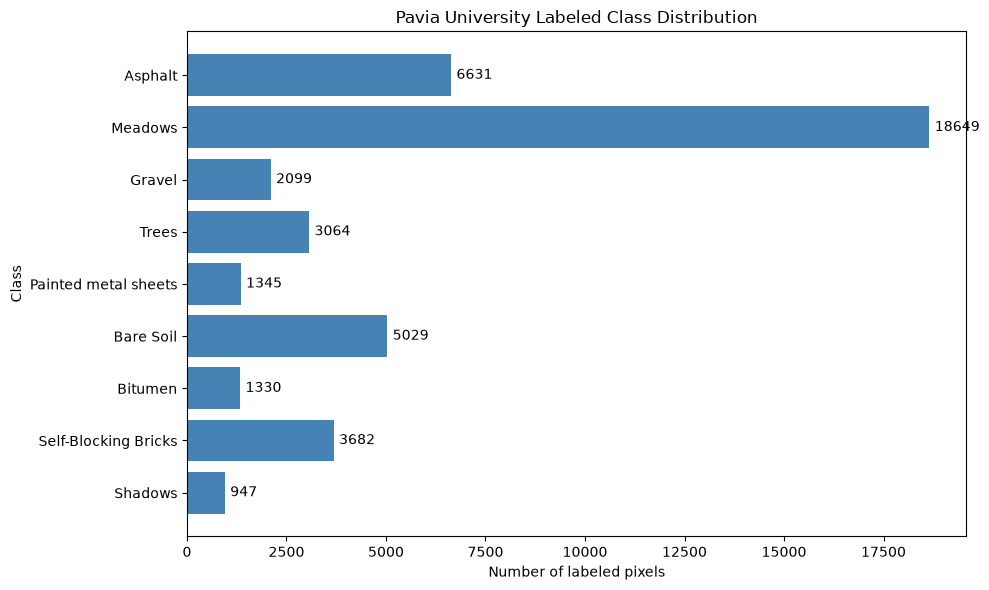

In [7]:
labeled_mask = labels != 0
labeled_labels = labels[labeled_mask]
labeled_counts = counts[labeled_mask]
labeled_names = [class_names[label] for label in labeled_labels]

fig, axis = plt.subplots(figsize=(10, 6))
bars = axis.barh(labeled_names, labeled_counts, color="steelblue")

axis.set_title("Pavia University Labeled Class Distribution")
axis.set_xlabel("Number of labeled pixels")
axis.set_ylabel("Class")
axis.invert_yaxis()
axis.bar_label(bars, padding=4)

plt.tight_layout()
plt.show()

### Mean Spectral Signatures

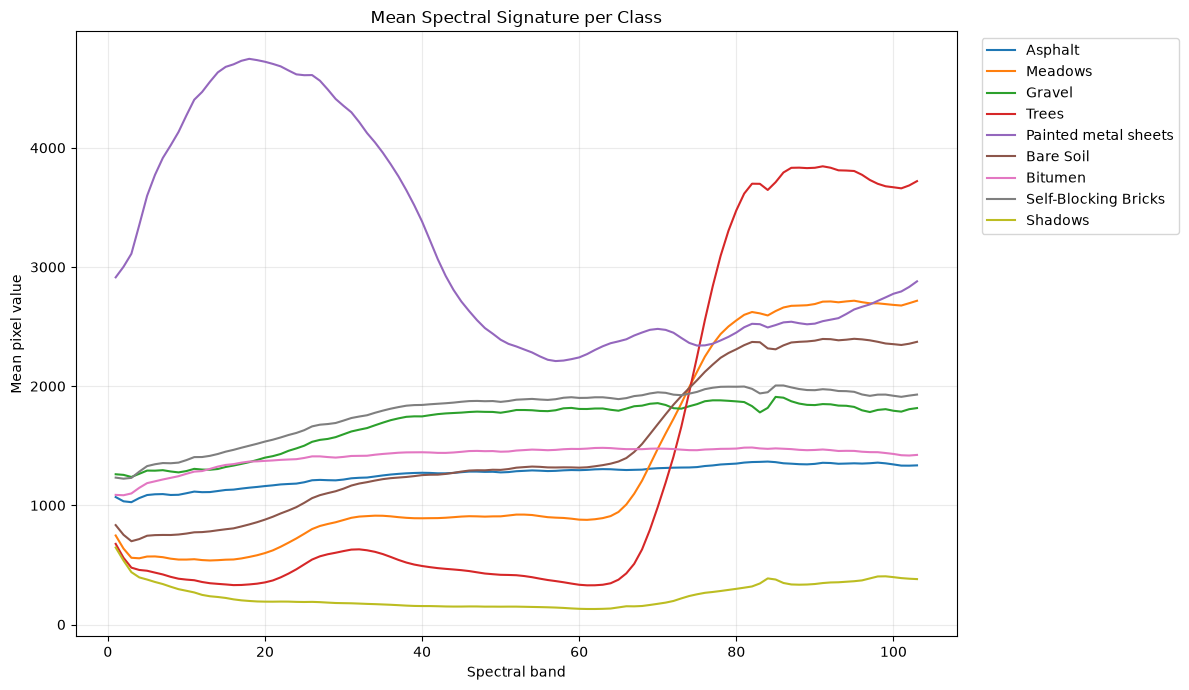

In [8]:
num_bands = cube.shape[2]
band_indices = np.arange(1, num_bands + 1)

fig, axis = plt.subplots(figsize=(12, 7))

for label in LABELED_CLASS_IDS:
    class_pixels = cube[ground_truth == label]
    mean_signature = class_pixels.mean(axis=0)

    axis.plot(
        band_indices,
        mean_signature,
        label=class_names[label],
    )

axis.set_title("Mean Spectral Signature per Class")
axis.set_xlabel("Spectral band")
axis.set_ylabel("Mean pixel value")
axis.grid(alpha=0.25)
axis.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

### Coordinates By Class

In [9]:
coordinates_by_class = {
    label: np.argwhere(ground_truth == label)
    for label in LABELED_CLASS_IDS
}

for label, coordinates in coordinates_by_class.items():
    expected_count = counts[labels == label].item()

    assert coordinates.shape == (expected_count, 2)
    print(
        f"{label}: {class_names[label]} - "
        f"{len(coordinates)} coordinates"
    )

total_coordinates = sum(
    len(coordinates)
    for coordinates in coordinates_by_class.values()
)

assert total_coordinates == np.count_nonzero(ground_truth)
print("Total labeled coordinates:", total_coordinates)

1: Asphalt - 6631 coordinates
2: Meadows - 18649 coordinates
3: Gravel - 2099 coordinates
4: Trees - 3064 coordinates
5: Painted metal sheets - 1345 coordinates
6: Bare Soil - 5029 coordinates
7: Bitumen - 1330 coordinates
8: Self-Blocking Bricks - 3682 coordinates
9: Shadows - 947 coordinates
Total labeled coordinates: 42776


### Few-Shot Coordinate Split

In [10]:
# Recreate the generator so rerunning this cell produces the same split.
rng = np.random.default_rng(SPLIT_SEED)

train_coordinates_by_class = {}
validation_coordinates_by_class = {}
test_coordinates_by_class = {}
excluded_coordinates_by_class = {}

for label, coordinates in coordinates_by_class.items():
    shuffled_coordinates = rng.permutation(coordinates)
    validation_end = (
        TRAIN_SAMPLES_PER_CLASS + VALIDATION_SAMPLES_PER_CLASS
    )

    train_coordinates_by_class[label] = shuffled_coordinates[
        :TRAIN_SAMPLES_PER_CLASS
    ]
    validation_coordinates_by_class[label] = shuffled_coordinates[
        TRAIN_SAMPLES_PER_CLASS:validation_end
    ]
    test_coordinates_by_class[label] = shuffled_coordinates[validation_end:]

all_selected_train_coordinates = np.vstack(
    list(train_coordinates_by_class.values())
)

def build_forbidden_test_center_mask(
    image_shape, train_coordinates, radius
):
    forbidden_mask = np.zeros(image_shape, dtype=bool)
    image_height, image_width = image_shape

    for row, column in train_coordinates:
        row_start = max(0, int(row) - radius)
        row_end = min(image_height, int(row) + radius + 1)
        column_start = max(0, int(column) - radius)
        column_end = min(image_width, int(column) + radius + 1)
        forbidden_mask[
            row_start:row_end, column_start:column_end
        ] = True

    return forbidden_mask

if DATA_SPLIT_TYPE == DataSplitType.RANDOM:
    forbidden_test_center_mask = np.zeros(
        ground_truth.shape, dtype=bool
    )
elif DATA_SPLIT_TYPE == DataSplitType.RANDOM_NO_CENTER_OVERLAP:
    forbidden_test_center_mask = build_forbidden_test_center_mask(
        ground_truth.shape,
        all_selected_train_coordinates,
        PATCH_RADIUS,
    )
elif DATA_SPLIT_TYPE == DataSplitType.RANDOM_NO_OVERLAP:
    forbidden_test_center_mask = build_forbidden_test_center_mask(
        ground_truth.shape,
        all_selected_train_coordinates,
        2 * PATCH_RADIUS,
    )
else:
    raise ValueError(f"Unsupported data split: {DATA_SPLIT_TYPE}")

for label in LABELED_CLASS_IDS:
    candidate_test_coordinates = test_coordinates_by_class[label]
    candidate_rows = candidate_test_coordinates[:, 0]
    candidate_columns = candidate_test_coordinates[:, 1]
    is_excluded = forbidden_test_center_mask[
        candidate_rows, candidate_columns
    ]

    test_coordinates_by_class[label] = candidate_test_coordinates[
        ~is_excluded
    ]
    excluded_coordinates_by_class[label] = candidate_test_coordinates[
        is_excluded
    ]

    print(
        f"{label}: {class_names[label]} - "
        f"train {len(train_coordinates_by_class[label])}, "
        f"validation {len(validation_coordinates_by_class[label])}, "
        f"test {len(test_coordinates_by_class[label])}, "
        f"excluded {len(excluded_coordinates_by_class[label])}"
    )

1: Asphalt - train 10, validation 5, test 6616
2: Meadows - train 10, validation 5, test 18634
3: Gravel - train 10, validation 5, test 2084
4: Trees - train 10, validation 5, test 3049
5: Painted metal sheets - train 10, validation 5, test 1330
6: Bare Soil - train 10, validation 5, test 5014
7: Bitumen - train 10, validation 5, test 1315
8: Self-Blocking Bricks - train 10, validation 5, test 3667
9: Shadows - train 10, validation 5, test 932


### Split Verification

In [11]:
def coordinate_set(coordinates):
    return {tuple(coordinate) for coordinate in coordinates.tolist()}


all_train_coordinates = set()
all_validation_coordinates = set()
all_test_coordinates = set()
all_excluded_coordinates = set()

for label in LABELED_CLASS_IDS:
    original_set = coordinate_set(coordinates_by_class[label])
    train_set = coordinate_set(train_coordinates_by_class[label])
    validation_set = coordinate_set(
        validation_coordinates_by_class[label]
    )
    test_set = coordinate_set(test_coordinates_by_class[label])
    excluded_set = coordinate_set(
        excluded_coordinates_by_class[label]
    )
    if not test_set:
        raise ValueError(
            f"{DATA_SPLIT_TYPE.value} leaves no test samples for "
            f"class {label} ({class_names[label]}). "
            "Choose another SPLIT_SEED or a less restrictive split."
        )

    assert len(train_set) == TRAIN_SAMPLES_PER_CLASS
    assert len(validation_set) == VALIDATION_SAMPLES_PER_CLASS
    assert train_set.isdisjoint(validation_set)
    assert train_set.isdisjoint(test_set)
    assert train_set.isdisjoint(excluded_set)
    assert validation_set.isdisjoint(test_set)
    assert validation_set.isdisjoint(excluded_set)
    assert test_set.isdisjoint(excluded_set)
    assert (
        train_set | validation_set | test_set | excluded_set
        == original_set
    )

    test_coordinates = test_coordinates_by_class[label]
    excluded_coordinates = excluded_coordinates_by_class[label]
    assert not forbidden_test_center_mask[
        test_coordinates[:, 0], test_coordinates[:, 1]
    ].any()
    assert forbidden_test_center_mask[
        excluded_coordinates[:, 0], excluded_coordinates[:, 1]
    ].all()

    all_train_coordinates.update(train_set)
    all_validation_coordinates.update(validation_set)
    all_test_coordinates.update(test_set)
    all_excluded_coordinates.update(excluded_set)

assert all_train_coordinates.isdisjoint(all_validation_coordinates)
assert all_train_coordinates.isdisjoint(all_test_coordinates)
assert all_train_coordinates.isdisjoint(all_excluded_coordinates)
assert all_validation_coordinates.isdisjoint(all_test_coordinates)
assert all_validation_coordinates.isdisjoint(all_excluded_coordinates)
assert all_test_coordinates.isdisjoint(all_excluded_coordinates)
expected_train_samples = NUM_CLASSES * TRAIN_SAMPLES_PER_CLASS
expected_validation_samples = (
    NUM_CLASSES * VALIDATION_SAMPLES_PER_CLASS
)
expected_excluded_samples = len(all_excluded_coordinates)
expected_test_samples = (
    total_coordinates
    - expected_train_samples
    - expected_validation_samples
    - expected_excluded_samples
)
assert len(all_train_coordinates) == expected_train_samples
assert len(all_validation_coordinates) == expected_validation_samples
assert len(all_test_coordinates) == expected_test_samples
assert (
    len(all_train_coordinates)
    + len(all_validation_coordinates)
    + len(all_test_coordinates)
    + len(all_excluded_coordinates)
    == total_coordinates
)

print("Train coordinates:", len(all_train_coordinates))
print("Validation coordinates:", len(all_validation_coordinates))
print("Test coordinates:", len(all_test_coordinates))
print("Excluded coordinates:", len(all_excluded_coordinates))
print("All split checks passed.")

Train coordinates: 90
Validation coordinates: 45
Test coordinates: 42641
All split checks passed.


### Save the Few-Shot Split

In [12]:
def build_split_table(coordinates_by_label):
    rows = []

    for label in LABELED_CLASS_IDS:
        coordinates = coordinates_by_label[label]
        label_column = np.full((len(coordinates), 1), label)
        rows.append(np.column_stack((coordinates, label_column)))

    return np.vstack(rows)


split_tables = {
    "train": build_split_table(train_coordinates_by_class),
    "validation": build_split_table(
        validation_coordinates_by_class
    ),
    "test": build_split_table(test_coordinates_by_class),
    "excluded": build_split_table(excluded_coordinates_by_class),
}

split_directory = project_root / "data" / "splits" / f"seed_{SPLIT_SEED}"
split_directory.mkdir(parents=True, exist_ok=True)
split_file_suffix = (
    ""
    if DATA_SPLIT_TYPE == DataSplitType.RANDOM
    else f"_{DATA_SPLIT_TYPE.value}"
)

for split_name, split_table in split_tables.items():
    output_path = split_directory / (
        f"{split_name}{split_file_suffix}.csv"
    )
    np.savetxt(
        output_path,
        split_table,
        fmt="%d",
        delimiter=",",
        header="row,column,label",
        comments="",
    )
    print(f"Saved {len(split_table)} samples to {output_path}")

Saved 90 samples to c:\Users\alex1\Documents\Cloned Repositories\Hyperspectral-Neural-Networks-Project\data\splits\seed_42\train.csv
Saved 45 samples to c:\Users\alex1\Documents\Cloned Repositories\Hyperspectral-Neural-Networks-Project\data\splits\seed_42\validation.csv
Saved 42641 samples to c:\Users\alex1\Documents\Cloned Repositories\Hyperspectral-Neural-Networks-Project\data\splits\seed_42\test.csv


### Reload and Verify the Saved Split

In [13]:
loaded_split_tables = {}

for split_name, expected_table in split_tables.items():
    input_path = split_directory / (
        f"{split_name}{split_file_suffix}.csv"
    )
    assert input_path.exists()
    if len(expected_table) == 0:
        loaded_table = np.empty((0, 3), dtype=np.int64)
    else:
        loaded_table = np.atleast_2d(
            np.loadtxt(
                input_path,
                delimiter=",",
                skiprows=1,
                dtype=np.int64,
            )
        )
    loaded_split_tables[split_name] = loaded_table

    assert loaded_table.shape == expected_table.shape
    assert np.array_equal(loaded_table, expected_table)

    rows = loaded_table[:, 0]
    columns = loaded_table[:, 1]
    saved_labels = loaded_table[:, 2]
    assert np.array_equal(ground_truth[rows, columns], saved_labels)

    print(f"Verified {input_path.name}: {len(loaded_table)} samples")

print(f"Saved split verified successfully for seed {SPLIT_SEED}.")

Verified train.csv: 90 samples
Verified validation.csv: 45 samples
Verified test.csv: 42641 samples
Saved split verified successfully for seed 42.


### Border Analysis for Patch Extraction

In [14]:
image_height, image_width = ground_truth.shape

for split_name, split_table in loaded_split_tables.items():
    rows = split_table[:, 0]
    columns = split_table[:, 1]

    requires_padding = (
        (rows < PATCH_RADIUS)
        | (rows >= image_height - PATCH_RADIUS)
        | (columns < PATCH_RADIUS)
        | (columns >= image_width - PATCH_RADIUS)
    )

    border_count = np.count_nonzero(requires_padding)
    print(
        f"{split_name}: {border_count} of {len(split_table)} samples "
        "require padding"
    )

train: 3 of 90 samples require padding
validation: 1 of 45 samples require padding
test: 3297 of 42641 samples require padding


### Per-Band Min-Max Normalization

In [15]:
cube_float = cube.astype(np.float32)

band_min = cube_float.min(axis=(0, 1), keepdims=True)
band_max = cube_float.max(axis=(0, 1), keepdims=True)
band_range = band_max - band_min

constant_band_indices = np.flatnonzero(band_range.reshape(-1) == 0)
if len(constant_band_indices) > 0:
    raise ValueError(
        f"Constant spectral bands found: {constant_band_indices.tolist()}"
    )

normalized_cube = (cube_float - band_min) / band_range

assert normalized_cube.shape == cube.shape
assert normalized_cube.dtype == np.float32
assert not np.shares_memory(normalized_cube, cube)
assert np.allclose(normalized_cube.min(axis=(0, 1)), 0.0)
assert np.allclose(normalized_cube.max(axis=(0, 1)), 1.0)

print("Normalized cube shape:", normalized_cube.shape)
print("Normalized cube dtype:", normalized_cube.dtype)
print("Normalized range:", normalized_cube.min(), normalized_cube.max())
print("Raw cube remains unchanged:", cube.dtype, cube.min(), cube.max())

Normalized cube shape: (610, 340, 103)
Normalized cube dtype: float32
Normalized range: 0.0 1.0
Raw cube remains unchanged: uint16 0 8000


### Reflect Padding

In [16]:
original_cube_shape = cube.shape
original_cube_dtype = cube.dtype

padded_cube = np.pad(
    normalized_cube,
    (
        (PATCH_RADIUS, PATCH_RADIUS),
        (PATCH_RADIUS, PATCH_RADIUS),
        (0, 0),
    ),
    mode="reflect",
)

expected_padded_shape = (
    normalized_cube.shape[0] + 2 * PATCH_RADIUS,
    normalized_cube.shape[1] + 2 * PATCH_RADIUS,
    normalized_cube.shape[2],
)
restored_normalized_cube = padded_cube[
    PATCH_RADIUS:-PATCH_RADIUS,
    PATCH_RADIUS:-PATCH_RADIUS,
    :,
]

assert cube.shape == original_cube_shape
assert cube.dtype == original_cube_dtype
assert padded_cube.shape == expected_padded_shape
assert padded_cube.dtype == normalized_cube.dtype
assert not np.shares_memory(normalized_cube, padded_cube)
assert np.array_equal(restored_normalized_cube, normalized_cube)

print("Normalized cube shape:", normalized_cube.shape)
print("Padded cube shape:", padded_cube.shape)
print("Raw cube remains unchanged.")

Normalized cube shape: (610, 340, 103)
Padded cube shape: (624, 354, 103)
Raw cube remains unchanged.


### Single Patch Extraction Check

In [17]:
sample_row, sample_column, sample_label = loaded_split_tables[
    "train"
][0]

sample_row = int(sample_row)
sample_column = int(sample_column)
sample_label = int(sample_label)

sample_patch = padded_cube[
    sample_row:sample_row + int(PATCH_SIZE),
    sample_column:sample_column + int(PATCH_SIZE),
    :,
]

expected_patch_shape = (int(PATCH_SIZE), int(PATCH_SIZE), cube.shape[2])
center_spectrum = sample_patch[PATCH_RADIUS, PATCH_RADIUS, :]

assert sample_patch.shape == expected_patch_shape
assert np.array_equal(
    center_spectrum,
    normalized_cube[sample_row, sample_column, :],
)
assert ground_truth[sample_row, sample_column] == sample_label
assert sample_label != 0

print("Coordinate:", (sample_row, sample_column))
print("Target:", sample_label, class_names[sample_label])
print("Patch shape:", sample_patch.shape)
print("Center pixel and target verified.")

Coordinate: (229, 29)
Target: 1 Asphalt
Patch shape: (15, 15, 103)
Center pixel and target verified.


### Reusable Patch Extraction

In [18]:
def extract_patch(row, column):
    patch = padded_cube[
        row:row + int(PATCH_SIZE),
        column:column + int(PATCH_SIZE),
        :,
    ]

    expected_shape = (
        int(PATCH_SIZE),
        int(PATCH_SIZE),
        cube.shape[2],
    )
    if patch.shape != expected_shape:
        raise ValueError(
            f"Invalid patch shape {patch.shape} at {(row, column)}"
        )

    return patch


all_saved_samples = np.vstack(list(loaded_split_tables.values()))
saved_rows = all_saved_samples[:, 0]
saved_columns = all_saved_samples[:, 1]

border_mask = (
    (saved_rows < PATCH_RADIUS)
    | (saved_rows >= ground_truth.shape[0] - PATCH_RADIUS)
    | (saved_columns < PATCH_RADIUS)
    | (saved_columns >= ground_truth.shape[1] - PATCH_RADIUS)
)
border_row, border_column, border_label = all_saved_samples[border_mask][0]
border_row = int(border_row)
border_column = int(border_column)
border_label = int(border_label)

border_patch = extract_patch(border_row, border_column)
border_center = border_patch[PATCH_RADIUS, PATCH_RADIUS, :]

assert border_patch.shape == (
    int(PATCH_SIZE),
    int(PATCH_SIZE),
    cube.shape[2],
)
assert np.array_equal(
    border_center,
    normalized_cube[border_row, border_column, :],
)
assert ground_truth[border_row, border_column] == border_label

print("Border coordinate:", (border_row, border_column))
print("Target:", border_label, class_names[border_label])
print("Patch shape:", border_patch.shape)
print("Border patch verified.")

Border coordinate: (69, 2)
Target: 1 Asphalt
Patch shape: (15, 15, 103)
Border patch verified.


### PyTorch Patch Dataset

This portion of the code reads the CSV file with the saved split and from the normalized and padded data, estracts patch of the wanted size, adjust for model class logits.

We also convert numeric types to float32 and we use *ascontigousarray* for efficiency

In [19]:
class HyperspectralPatchDataset(Dataset):
    def __init__(self, padded_hsi_cube, split_table, patch_size):
        self.padded_hsi_cube = padded_hsi_cube
        self.coordinates = split_table[:, :2].astype(np.int64)
        self.targets = split_table[:, 2].astype(np.int64) - 1
        self.patch_size = int(patch_size)

        assert self.coordinates.shape == (len(split_table), 2)
        assert self.targets.min() >= 0
        assert self.targets.max() < NUM_CLASSES

    def __len__(self):
        return len(self.coordinates)

    def __getitem__(self, index):
        row, column = self.coordinates[index]
        patch = self.padded_hsi_cube[
            row:row + self.patch_size,
            column:column + self.patch_size,
            :,
        ]
        patch = np.ascontiguousarray(
            patch.transpose(2, 0, 1),
            dtype=np.float32,
        )

        patch_tensor = torch.from_numpy(patch)
        target_tensor = torch.tensor(
            self.targets[index],
            dtype=torch.long,
        )
        return patch_tensor, target_tensor


train_dataset = HyperspectralPatchDataset(
    padded_cube, loaded_split_tables["train"], PATCH_SIZE
)
validation_dataset = HyperspectralPatchDataset(
    padded_cube, loaded_split_tables["validation"], PATCH_SIZE
)
test_dataset = HyperspectralPatchDataset(
    padded_cube, loaded_split_tables["test"], PATCH_SIZE
)

example_patch, example_target = train_dataset[0]
example_row, example_column = train_dataset.coordinates[0]

assert len(train_dataset) == expected_train_samples
assert len(validation_dataset) == expected_validation_samples
assert len(test_dataset) == expected_test_samples
assert example_patch.shape == (
    cube.shape[2], int(PATCH_SIZE), int(PATCH_SIZE)
)
assert example_patch.dtype == torch.float32
assert example_target.dtype == torch.long
assert torch.equal(
    example_patch[:, PATCH_RADIUS, PATCH_RADIUS],
    torch.from_numpy(
        normalized_cube[example_row, example_column, :]
    ),
)

print("Dataset sizes:", len(train_dataset), len(validation_dataset), len(test_dataset))
print("Patch tensor shape:", tuple(example_patch.shape))
print("Target index:", example_target.item())
print("Original class label:", example_target.item() + 1)

Dataset sizes: 90 45 42641
Patch tensor shape: (103, 15, 15)
Target index: 0
Original class label: 1


### PyTorch DataLoaders

In [20]:
train_loader_generator = torch.Generator().manual_seed(TRAINING_SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    generator=train_loader_generator,
)
validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

batch_patches, batch_targets = next(iter(validation_loader))
train_class_counts = np.bincount(
    train_dataset.targets, minlength=NUM_CLASSES
)

assert batch_patches.shape == (
    BATCH_SIZE, cube.shape[2], int(PATCH_SIZE), int(PATCH_SIZE)
)
assert batch_targets.shape == (BATCH_SIZE,)
assert batch_patches.dtype == torch.float32
assert batch_targets.dtype == torch.long
assert batch_targets.min() >= 0
assert batch_targets.max() < NUM_CLASSES
assert np.array_equal(
    train_class_counts,
    np.full(NUM_CLASSES, TRAIN_SAMPLES_PER_CLASS),
)

print("Batch shape:", tuple(batch_patches.shape))
print("Target shape:", tuple(batch_targets.shape))
print("Batches per epoch:", len(train_loader))
print("Validation batches:", len(validation_loader))
print("Test batches:", len(test_loader))
print("Training samples per class:", train_class_counts.tolist())

Batch shape: (32, 103, 15, 15)
Target shape: (32,)
Batches per epoch: 3
Validation batches: 2
Test batches: 1333
Training samples per class: [10, 10, 10, 10, 10, 10, 10, 10, 10]


## CNN-Only Baseline

### Multiscale CNN Block

In [21]:
class MultiscaleCNNBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.branch_1x1 = nn.Conv2d(
            channels, channels, kernel_size=1
        )
        self.branch_3x3 = nn.Conv2d(
            channels, channels, kernel_size=3, padding=1
        )
        self.branch_two_3x3 = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels),
            nn.GELU(),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
        )
        self.branch_three_3x3 = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels),
            nn.GELU(),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels),
            nn.GELU(),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
        )

        self.fusion = nn.Conv2d(
            4 * channels, channels, kernel_size=1
        )

    def forward(self, features):
        branch_features = [
            self.branch_1x1(features),
            self.branch_3x3(features),
            self.branch_two_3x3(features),
            self.branch_three_3x3(features),
        ]
        concatenated_features = torch.cat(branch_features, dim=1)
        fused_features = self.fusion(concatenated_features)
        return features + fused_features


cnn_block = MultiscaleCNNBlock(FEATURE_CHANNELS)
cnn_block.eval()

dummy_features = torch.randn(
    2, FEATURE_CHANNELS, int(PATCH_SIZE), int(PATCH_SIZE)
)
with torch.no_grad():
    dummy_output = cnn_block(dummy_features)

assert dummy_output.shape == dummy_features.shape

print("Input shape:", tuple(dummy_features.shape))
print("Output shape:", tuple(dummy_output.shape))
print("CNN block preserves channel and spatial dimensions.")

Input shape: (2, 128, 15, 15)
Output shape: (2, 128, 15, 15)
CNN block preserves channel and spatial dimensions.


### CNN-Only Classifier

In [22]:
class CNNOnlyBaseline(nn.Module):
    def __init__(self, input_channels, feature_channels, num_classes):
        super().__init__()

        self.input_projection = nn.Conv2d(
            input_channels, feature_channels, kernel_size=1
        )
        self.cnn_block = MultiscaleCNNBlock(feature_channels)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(feature_channels, num_classes)

    def forward(self, patches):
        features = self.input_projection(patches)
        cnn_features = self.cnn_block(features)

        # Level 3: pass `features` to the Transformer in parallel here,
        # then concatenate its output with `cnn_features`.

        pooled_features = self.global_pool(cnn_features)
        pooled_features = pooled_features.flatten(start_dim=1)
        return self.classifier(pooled_features)


cnn_baseline = CNNOnlyBaseline(
    input_channels=cube.shape[2],
    feature_channels=FEATURE_CHANNELS,
    num_classes=NUM_CLASSES,
)
cnn_baseline.eval()

example_batch = example_patch.unsqueeze(0)
with torch.no_grad():
    projected_features = cnn_baseline.input_projection(example_batch)
    example_logits = cnn_baseline(example_batch)

assert projected_features.shape == (
    1, FEATURE_CHANNELS, int(PATCH_SIZE), int(PATCH_SIZE)
)
assert example_logits.shape == (1, NUM_CLASSES)

print("Input shape:", tuple(example_batch.shape))
print("Projected feature shape:", tuple(projected_features.shape))
print("Logits shape:", tuple(example_logits.shape))

Input shape: (1, 103, 15, 15)
Projected feature shape: (1, 128, 15, 15)
Logits shape: (1, 9)


### Forward and Backward Sanity Check

In [23]:
sanity_indices = [
    np.flatnonzero(train_dataset.targets == class_index)[0]
    for class_index in range(NUM_CLASSES)
]
sanity_samples = [
    train_dataset[int(index)] for index in sanity_indices
]
sanity_patches = torch.stack([sample[0] for sample in sanity_samples])
sanity_targets = torch.stack([sample[1] for sample in sanity_samples])

torch.manual_seed(TRAINING_SEED)
sanity_model = CNNOnlyBaseline(
    input_channels=cube.shape[2],
    feature_channels=FEATURE_CHANNELS,
    num_classes=NUM_CLASSES,
)
sanity_model.train()

criterion = nn.CrossEntropyLoss()
sanity_logits = sanity_model(sanity_patches)
sanity_loss = criterion(sanity_logits, sanity_targets)
sanity_loss.backward()

gradients = [
    parameter.grad
    for parameter in sanity_model.parameters()
    if parameter.grad is not None
]
gradient_norm = sum(gradient.norm().item() for gradient in gradients)

assert sanity_patches.shape == (
    NUM_CLASSES, cube.shape[2], int(PATCH_SIZE), int(PATCH_SIZE)
)
assert torch.equal(sanity_targets, torch.arange(NUM_CLASSES))
assert sanity_logits.shape == (NUM_CLASSES, NUM_CLASSES)
assert torch.isfinite(sanity_loss)
assert gradients
assert all(torch.isfinite(gradient).all() for gradient in gradients)
assert gradient_norm > 0

sanity_model.zero_grad(set_to_none=True)

print("Sanity batch shape:", tuple(sanity_patches.shape))
print("Targets:", sanity_targets.tolist())
print("Logits shape:", tuple(sanity_logits.shape))
print("Loss:", sanity_loss.item())
print("Gradient norm:", gradient_norm)
print("Forward and backward checks passed.")

Sanity batch shape: (9, 103, 15, 15)
Targets: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Logits shape: (9, 9)
Loss: 2.1928460597991943
Gradient norm: 4.480462450991487
Forward and backward checks passed.


### Small-Batch Overfitting Test

In [24]:
torch.manual_seed(TRAINING_SEED)
overfit_model = CNNOnlyBaseline(
    input_channels=cube.shape[2],
    feature_channels=FEATURE_CHANNELS,
    num_classes=NUM_CLASSES,
)
overfit_model.train()

overfit_criterion = nn.CrossEntropyLoss()
overfit_optimizer = torch.optim.Adam(
    overfit_model.parameters(),
    lr=OVERFIT_LEARNING_RATE,
)

initial_loss = None
for step in range(1, OVERFIT_MAX_STEPS + 1):
    overfit_optimizer.zero_grad()
    logits = overfit_model(sanity_patches)
    loss = overfit_criterion(logits, sanity_targets)

    if initial_loss is None:
        initial_loss = loss.item()

    loss.backward()
    overfit_optimizer.step()

    predictions = logits.argmax(dim=1)
    accuracy = (predictions == sanity_targets).float().mean().item()

    if (
        step >= OVERFIT_MIN_STEPS
        and accuracy == 1.0
        and loss.item() < OVERFIT_TARGET_LOSS
    ):
        break

overfit_model.eval()
with torch.no_grad():
    final_logits = overfit_model(sanity_patches)
    final_loss = overfit_criterion(final_logits, sanity_targets).item()
    final_predictions = final_logits.argmax(dim=1)
    final_accuracy = (
        (final_predictions == sanity_targets).float().mean().item()
    )

assert final_loss < initial_loss
assert final_loss < OVERFIT_TARGET_LOSS
assert final_accuracy == 1.0

print("Steps:", step)
print("Initial loss:", initial_loss)
print("Final loss:", final_loss)
print("Final accuracy:", final_accuracy)
print("Small-batch overfitting test passed.")

Steps: 50
Initial loss: 2.1928460597991943
Final loss: 5.6670545745873824e-05
Final accuracy: 1.0
Small-batch overfitting test passed.


## CNN-Only Training

### Training Configuration

In [25]:
torch.manual_seed(TRAINING_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(TRAINING_SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = CNNOnlyBaseline(
    input_channels=cube.shape[2],
    feature_channels=FEATURE_CHANNELS,
    num_classes=NUM_CLASSES,
).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
)

def build_lr_scheduler(optimizer, scheduling_type, total_epochs):
    if scheduling_type == LRSchedulingType.FIXED:
        return None
    if scheduling_type == LRSchedulingType.COSINEANNEALING:
        return torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=total_epochs
        )
    if scheduling_type == LRSchedulingType.REDUCELRONPLATEAU:
        return torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", patience=2
        )
    raise ValueError(f"Unsupported LR scheduling: {scheduling_type}")

run_name = (
    RunMode.FULL.value
    if RUN_FULL_TRAINING
    else RunMode.SMOKE.value
)
epochs_to_run = (
    EPOCHS if RUN_FULL_TRAINING else SMOKE_TEST_EPOCHS
)
scheduler = build_lr_scheduler(
    optimizer, LR_SCHEDULING, epochs_to_run
)
checkpoint_path = (
    project_root
    / "outputs"
    / "checkpoints"
    / (
        f"cnn_{run_name}_p{int(PATCH_SIZE)}_e{epochs_to_run}_"
        f"f{FEATURE_CHANNELS}_lr{LR_SCHEDULING.value}_"
        f"split{SPLIT_SEED}_{DATA_SPLIT_TYPE.value}_"
        f"train{TRAINING_SEED}.pt"
    )
)
trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Device:", device)
print("Epochs:", epochs_to_run)
print("Learning rate:", LEARNING_RATE)
print("LR scheduling:", LR_SCHEDULING.value)
print("Data split:", DATA_SPLIT_TYPE.value)
print("Trainable parameters:", trainable_parameters)
print("Checkpoint:", checkpoint_path)

Device: cpu
Epochs: 150
Learning rate: 8e-05
LR scheduling: fixed
Trainable parameters: 982921
Checkpoint: c:\Users\alex1\Documents\Cloned Repositories\Hyperspectral-Neural-Networks-Project\outputs\checkpoints\cnn_full_p15_e150_f128_lrfixed_split42_train100.pt


### Training and Validation Functions

In [26]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for patches, targets in loader:
        patches = patches.to(device)
        targets = targets.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(patches)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        batch_size = targets.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == targets).sum().item()
        total_samples += batch_size

    epoch_loss = total_loss / total_samples
    epoch_accuracy = total_correct / total_samples
    return epoch_loss, epoch_accuracy


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for patches, targets in loader:
        patches = patches.to(device)
        targets = targets.to(device)

        logits = model(patches)
        loss = criterion(logits, targets)

        batch_size = targets.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == targets).sum().item()
        total_samples += batch_size

    average_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    return average_loss, accuracy


print("Training and validation functions ready.")

Training and validation functions ready.


### Model Training

In [27]:
checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

history = {
    "train_loss": [],
    "train_accuracy": [],
    "validation_loss": [],
    "validation_accuracy": [],
    "learning_rate": [],
}
best_validation_loss = float("inf")
best_epoch = 0

for epoch in range(1, epochs_to_run + 1):
    train_loss, train_accuracy = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )
    validation_loss, validation_accuracy = evaluate(
        model, validation_loader, criterion, device
    )
    current_learning_rate = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["validation_loss"].append(validation_loss)
    history["validation_accuracy"].append(validation_accuracy)
    history["learning_rate"].append(current_learning_rate)

    if scheduler is not None:
        if LR_SCHEDULING == LRSchedulingType.REDUCELRONPLATEAU:
            scheduler.step(validation_loss)
        else:
            scheduler.step()

    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        best_epoch = epoch
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": (
                    scheduler.state_dict()
                    if scheduler is not None
                    else None
                ),
                "validation_loss": validation_loss,
                "validation_accuracy": validation_accuracy,
                "split_seed": SPLIT_SEED,
                "data_split_type": DATA_SPLIT_TYPE.value,
                "training_seed": TRAINING_SEED,
                "feature_channels": FEATURE_CHANNELS,
                "patch_size": int(PATCH_SIZE),
                "num_classes": NUM_CLASSES,
                "run_mode": run_name,
                "batch_size": BATCH_SIZE,
                "learning_rate": LEARNING_RATE,
                "lr_scheduling": LR_SCHEDULING.value,
                "epochs_requested": epochs_to_run,
                "history": history,
            },
            checkpoint_path,
        )

    if epoch == 1 or epoch % 10 == 0 or epoch == epochs_to_run:
        print(
            f"Epoch {epoch:03d}/{epochs_to_run:03d} | "
            f"train loss {train_loss:.4f}, acc {train_accuracy:.4f} | "
            f"val loss {validation_loss:.4f}, "
            f"acc {validation_accuracy:.4f} | "
            f"lr {current_learning_rate:.2e}"
        )

print("Best epoch:", best_epoch)
print("Best validation loss:", best_validation_loss)
print("Checkpoint saved to:", checkpoint_path)

Epoch 001/150 | train loss 2.1557, acc 0.1222 | val loss 2.1925, acc 0.1111 | lr 8.00e-05
Epoch 010/150 | train loss 1.3928, acc 0.4556 | val loss 1.9763, acc 0.3333 | lr 8.00e-05
Epoch 020/150 | train loss 0.9014, acc 0.7000 | val loss 1.1151, acc 0.6444 | lr 8.00e-05
Epoch 030/150 | train loss 0.6511, acc 0.7333 | val loss 0.9068, acc 0.6222 | lr 8.00e-05
Epoch 040/150 | train loss 0.4472, acc 0.8667 | val loss 0.7085, acc 0.7333 | lr 8.00e-05
Epoch 050/150 | train loss 0.3431, acc 0.9333 | val loss 0.5886, acc 0.7333 | lr 8.00e-05
Epoch 060/150 | train loss 0.2760, acc 0.9444 | val loss 0.4479, acc 0.8444 | lr 8.00e-05
Epoch 070/150 | train loss 0.1990, acc 0.9667 | val loss 0.4994, acc 0.8000 | lr 8.00e-05
Epoch 080/150 | train loss 0.1591, acc 0.9889 | val loss 0.7083, acc 0.7111 | lr 8.00e-05
Epoch 090/150 | train loss 0.1368, acc 0.9667 | val loss 0.3836, acc 0.8889 | lr 8.00e-05
Epoch 100/150 | train loss 0.0949, acc 0.9889 | val loss 0.4380, acc 0.7778 | lr 8.00e-05
Epoch 110/

### Training Curves

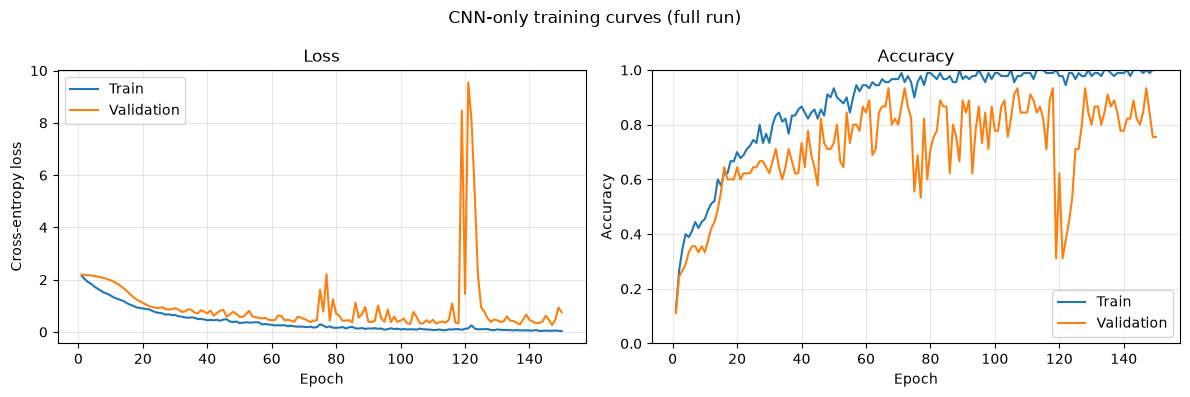

In [28]:
epochs = range(1, len(history["train_loss"]) + 1)

figure, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history["train_loss"], label="Train")
axes[0].plot(epochs, history["validation_loss"], label="Validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(epochs, history["train_accuracy"], label="Train")
axes[1].plot(epochs, history["validation_accuracy"], label="Validation")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.3)
axes[1].legend()

figure.suptitle(f"CNN-only training curves ({run_name} run)")
plt.tight_layout()
plt.show()

## CNN-Only Evaluation

In [29]:
best_checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=False,
)
model.load_state_dict(best_checkpoint["model_state_dict"])
model.eval()

test_targets = []
test_predictions = []

with torch.no_grad():
    for patches, targets in test_loader:
        patches = patches.to(device)
        logits = model(patches)
        predictions = logits.argmax(dim=1)

        test_targets.append(targets)
        test_predictions.append(predictions.cpu())

test_targets = torch.cat(test_targets).numpy()
test_predictions = torch.cat(test_predictions).numpy()

assert len(test_targets) == len(test_dataset)
print("Loaded checkpoint epoch:", best_checkpoint["epoch"])
print("Checkpoint validation loss:", best_checkpoint["validation_loss"])
print("Test predictions:", len(test_predictions))

Loaded checkpoint epoch: 147
Checkpoint validation loss: 0.2676586237218645
Test predictions: 42641


### Test Metrics

OA: 0.8417
AA: 0.8924
Kappa: 0.7973
Per-class accuracy:
  1 Asphalt: 0.9219
  2 Meadows: 0.7924
  3 Gravel: 0.9544
  4 Trees: 0.9141
  5 Painted metal sheets: 0.9481
  6 Bare Soil: 0.8269
  7 Bitumen: 0.9749
  8 Self-Blocking Bricks: 0.7243
  9 Shadows: 0.9742


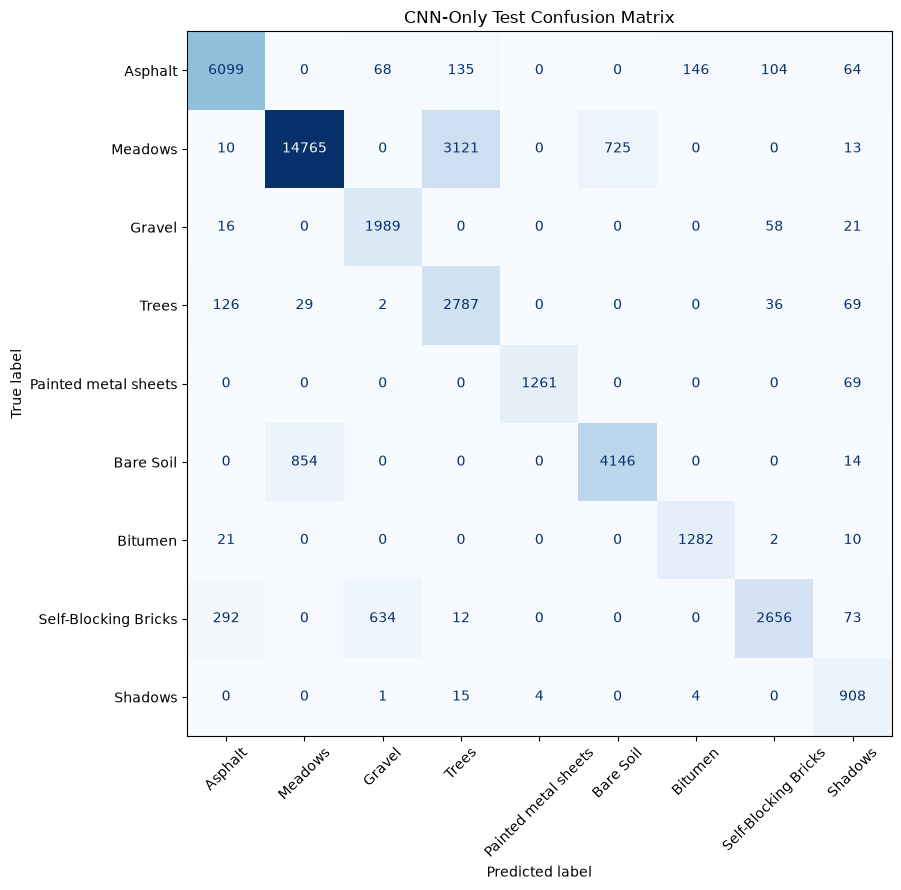

In [30]:
class_indices = np.arange(NUM_CLASSES)
confusion = confusion_matrix(
    test_targets,
    test_predictions,
    labels=class_indices,
)
per_class_accuracy = np.divide(
    np.diag(confusion),
    confusion.sum(axis=1),
    out=np.zeros(NUM_CLASSES, dtype=float),
    where=confusion.sum(axis=1) != 0,
)
overall_accuracy = accuracy_score(test_targets, test_predictions)
average_accuracy = per_class_accuracy.mean()
kappa = cohen_kappa_score(test_targets, test_predictions)

print(f"OA: {overall_accuracy:.4f}")
print(f"AA: {average_accuracy:.4f}")
print(f"Kappa: {kappa:.4f}")
print("Per-class accuracy:")
for class_index, class_accuracy in enumerate(per_class_accuracy):
    original_label = class_index + 1
    print(
        f"  {original_label} {class_names[original_label]}: "
        f"{class_accuracy:.4f}"
    )

display_names = [class_names[label] for label in LABELED_CLASS_IDS]
figure, axis = plt.subplots(figsize=(11, 9))
ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=display_names,
).plot(ax=axis, cmap="Blues", xticks_rotation=45, colorbar=False)
axis.set_title("CNN-Only Test Confusion Matrix")
plt.tight_layout()
plt.show()

### Normalized Confusion Matrix

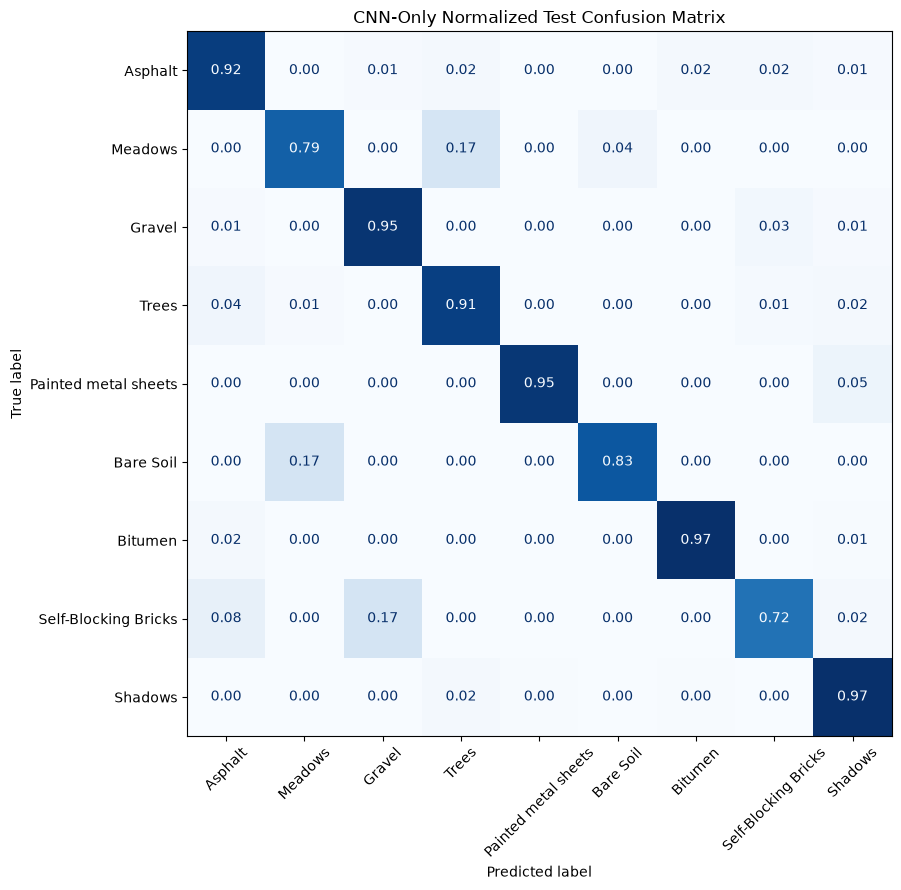

In [31]:
row_totals = confusion.sum(axis=1, keepdims=True)
normalized_confusion = np.divide(
    confusion,
    row_totals,
    out=np.zeros_like(confusion, dtype=float),
    where=row_totals != 0,
)

figure, axis = plt.subplots(figsize=(11, 9))
ConfusionMatrixDisplay(
    confusion_matrix=normalized_confusion,
    display_labels=display_names,
).plot(
    ax=axis,
    cmap="Blues",
    values_format=".2f",
    xticks_rotation=45,
    colorbar=False,
)
axis.set_title("CNN-Only Normalized Test Confusion Matrix")
plt.tight_layout()
plt.show()

### CNN-Only Classification Map

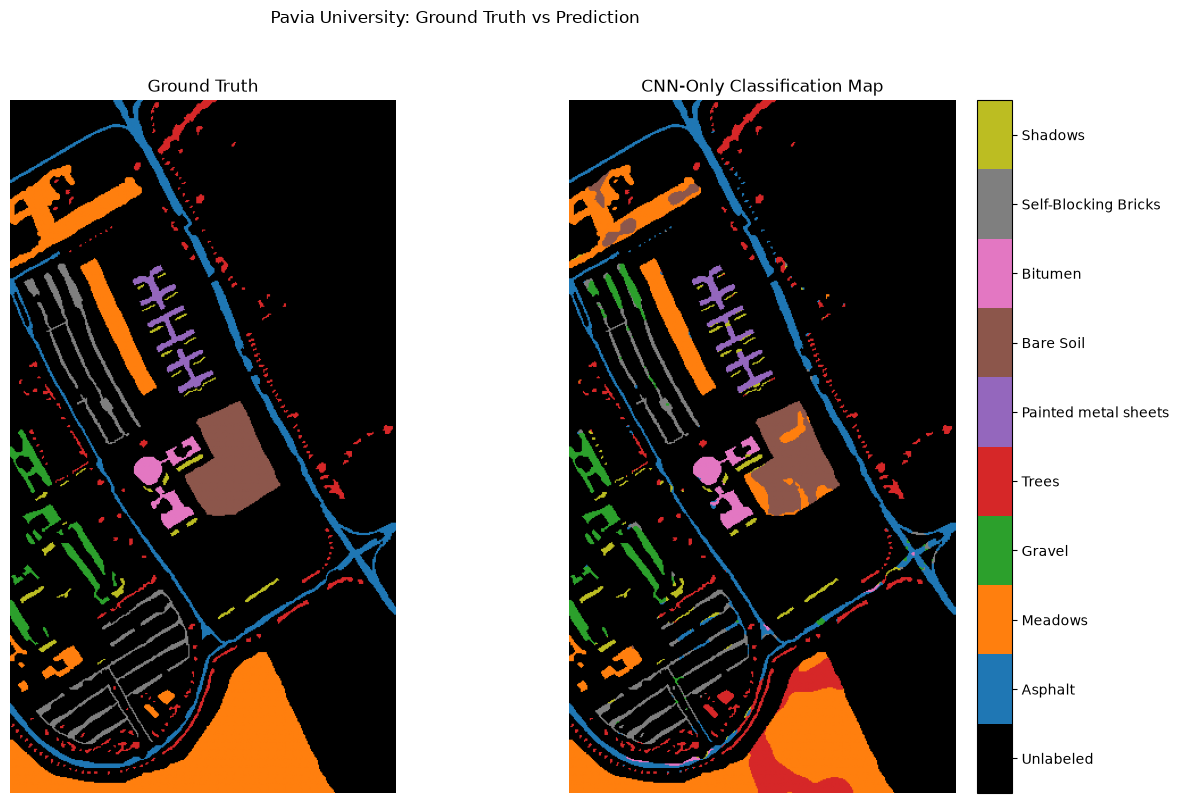

Mapped labeled pixels: 42776
Unlabeled pixels kept as background: 164624


In [32]:
# Test predictions are reused. Train, validation and excluded
# pixels are inferred here only to complete the visualization.
non_test_table = np.vstack(
    [
        loaded_split_tables[SplitName.TRAIN.value],
        loaded_split_tables[SplitName.VALIDATION.value],
        loaded_split_tables[SplitName.EXCLUDED.value],
    ]
)
non_test_dataset = HyperspectralPatchDataset(
    padded_cube, non_test_table, PATCH_SIZE
)
non_test_loader = DataLoader(
    non_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

non_test_predictions = []
model.eval()
with torch.no_grad():
    for patches, _ in non_test_loader:
        logits = model(patches.to(device))
        non_test_predictions.append(
            logits.argmax(dim=1).cpu()
        )

non_test_predictions = torch.cat(
    non_test_predictions
).numpy()

classification_map = np.zeros_like(ground_truth, dtype=np.uint8)
test_rows, test_columns = test_dataset.coordinates.T
classification_map[test_rows, test_columns] = (
    test_predictions + 1
)
non_test_rows, non_test_columns = (
    non_test_dataset.coordinates.T
)
classification_map[
    non_test_rows, non_test_columns
] = non_test_predictions + 1

labeled_mask = ground_truth != PaviaClass.UNLABELED
assert classification_map.shape == ground_truth.shape
assert np.all(classification_map[~labeled_mask] == 0)
assert np.all(classification_map[labeled_mask] != 0)

classification_colors = ["black"] + list(
    plt.get_cmap("tab10").colors[:NUM_CLASSES]
)
classification_cmap = ListedColormap(classification_colors)

figure, axes = plt.subplots(1, 2, figsize=(14, 9))
for axis, image, title in zip(
    axes,
    [ground_truth, classification_map],
    ["Ground Truth", "CNN-Only Classification Map"],
):
    displayed_image = axis.imshow(
        image,
        cmap=classification_cmap,
        vmin=-0.5,
        vmax=NUM_CLASSES + 0.5,
    )
    axis.set_title(title)
    axis.axis("off")

colorbar = figure.colorbar(
    displayed_image,
    ax=axes,
    ticks=np.arange(NUM_CLASSES + 1),
    fraction=0.035,
    pad=0.02,
)
colorbar.ax.set_yticklabels(
    [class_names[label] for label in range(NUM_CLASSES + 1)]
)
figure.suptitle("Pavia University: Ground Truth vs Prediction")
plt.show()

print("Mapped labeled pixels:", np.count_nonzero(labeled_mask))
print("Unlabeled pixels kept as background:", (~labeled_mask).sum())